In [16]:
import tushare as ts
import numpy as np
import talib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings("ignore")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

ts.set_token('dae1a1067c40804e76e2b7cce0e87b366a099d29a829b0390468d8c6')
pro = ts.pro_api()

#### 股票基本数据获取

In [17]:
# 选取贵州茅台（600519.SH）的股票数据
df = pro.daily(ts_code='600519.SH', start_date='20210101', end_date='20260501')
df = df.sort_values('trade_date').reset_index(drop=True)
df

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,600519.SH,20210104,1999.98,2004.99,1983.81,1997.00,1998.00,-1.00,-0.0501,43514.00,8.686920e+06
1,600519.SH,20210105,1990.00,2059.45,1982.46,2059.45,1997.00,62.45,3.1272,52116.05,1.059256e+07
2,600519.SH,20210106,2064.80,2125.00,2036.03,2100.00,2059.45,40.55,1.9690,47410.20,9.882594e+06
3,600519.SH,20210107,2097.00,2140.00,2075.00,2140.00,2100.00,40.00,1.9048,37931.39,7.991179e+06
4,600519.SH,20210108,2142.00,2150.88,2063.02,2090.00,2140.00,-50.00,-2.3364,53861.64,1.134520e+07
...,...,...,...,...,...,...,...,...,...,...,...
1284,600519.SH,20260424,1413.10,1458.88,1413.10,1458.49,1419.00,39.49,2.7829,55455.31,8.003411e+06
1285,600519.SH,20260427,1420.00,1420.00,1402.20,1403.20,1458.49,-55.29,-3.7909,72797.74,1.023976e+07
1286,600519.SH,20260428,1402.00,1409.39,1400.11,1405.00,1403.20,1.80,0.1283,34004.42,4.772514e+06
1287,600519.SH,20260429,1405.00,1409.75,1400.28,1401.17,1405.00,-3.83,-0.2726,34813.13,4.881691e+06


#### 股票衍生变量生成

In [18]:
df['close-open'] = (df['close'] - df['open']) / df['open']
df['high-low'] = (df['high'] - df['low']) / df['low']
df['pre_close_c'] = df['close'].shift(1)
df['price_change_c'] = df['close'] - df['pre_close_c']
df['p_change_c'] = (df['close'] - df['pre_close_c']) / df['pre_close_c'] * 100
df['MA5'] = df['close'].rolling(5).mean()
df['MA10'] = df['close'].rolling(10).mean()
df['RSI'] = talib.RSI(df['close'], timeperiod=12)
df['MOM'] = talib.MOM(df['close'], timeperiod=5)
df['EMA12'] = talib.EMA(df['close'], timeperiod=12)
df['EMA26'] = talib.EMA(df['close'], timeperiod=26)
df['MACD'], df['MACDsignal'], df['MACDhist'] = talib.MACD(df['close'], fastperiod=12, slowperiod=26, signalperiod=9)
df['target'] = np.where(df['close'].shift(-1) > df['close'], 1, -1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,...,MA5,MA10,RSI,MOM,EMA12,EMA26,MACD,MACDsignal,MACDhist,target
0,600519.SH,20210225,2209.0,2224.50,2121.21,2150.00,2189.00,-39.00,-1.7816,59726.43,...,2278.804,2360.425,43.869863,-321.00,2286.056575,2226.628568,51.959263,80.026195,-28.066932,-1
1,600519.SH,20210226,2100.0,2179.95,2067.30,2122.78,2150.00,-27.22,-1.2660,66525.06,...,2211.360,2341.403,42.237267,-337.22,2260.937102,2218.936081,35.681314,71.157219,-35.475905,1
2,600519.SH,20210301,2179.0,2179.00,2120.00,2158.00,2122.78,35.22,1.6591,44916.26,...,2185.356,2320.323,45.120074,-130.02,2245.100625,2214.422298,25.330883,61.991952,-36.661069,-1
3,600519.SH,20210302,2180.0,2180.00,2033.00,2058.00,2158.00,-100.00,-4.6339,70764.50,...,2135.556,2280.480,39.079044,-249.00,2216.315913,2202.835461,8.955692,51.384700,-42.429008,1
4,600519.SH,20210303,2040.0,2149.77,2033.00,2140.00,2058.00,82.00,3.9845,54215.46,...,2125.756,2234.380,45.595058,-49.00,2204.575004,2198.180982,2.565378,41.620836,-39.055458,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,600519.SH,20260424,1413.1,1458.88,1413.10,1458.49,1419.00,39.49,2.7829,55455.31,...,1421.978,1433.768,56.964664,51.25,1434.064628,1436.321941,-2.257313,-0.585602,-1.671711,-1
1252,600519.SH,20260427,1420.0,1420.00,1402.20,1403.20,1458.49,-55.29,-3.7909,72797.74,...,1420.440,1429.757,42.352374,-7.69,1429.316224,1433.868464,-4.552240,-1.378930,-3.173311,1
1253,600519.SH,20260428,1402.0,1409.39,1400.11,1405.00,1403.20,1.80,0.1283,34004.42,...,1419.038,1425.567,42.872813,-7.01,1425.575266,1431.730059,-6.154793,-2.334102,-3.820691,-1
1254,600519.SH,20260429,1405.0,1409.75,1400.28,1401.17,1405.00,-3.83,-0.2726,34813.13,...,1417.372,1418.934,41.992821,-8.33,1421.820610,1429.466351,-7.645741,-3.396430,-4.249311,-1


#### 多因子模型搭建

In [19]:
features = ['close-open', 'high-low', 'p_change_c', 'MA5', 'MA10', 'RSI', 'MOM', 'EMA12', 'EMA26', 'MACD', 'MACDsignal', 'MACDhist']
X = df[features]
y = df['target']
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 模型使用与评估

In [20]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"初步准确率: {acc}")

初步准确率: 0.5753968253968254


#### 参数调优

In [21]:
param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5, 7]}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"最优参数: {grid_search.best_params_}")
print(f"调优后准确率: {accuracy_score(y_test, y_pred_best)}")

最优参数: {'max_depth': 5, 'n_estimators': 100}
调优后准确率: 0.5674603174603174


#### 收益回测曲线绘制

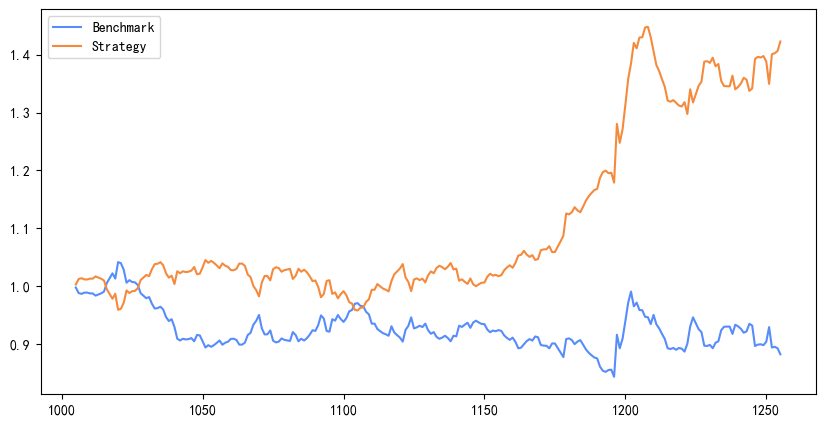

In [22]:
df_test = df.iloc[split_idx:].copy()
df_test['prediction'] = y_pred_best
df_test['return'] = df_test['close'].pct_change()
df_test['strategy_return'] = df_test['prediction'].shift(1) * df_test['return']
df_test.dropna(inplace=True)
df_test['cum_return'] = (1 + df_test['return']).cumprod()
df_test['cum_strategy_return'] = (1 + df_test['strategy_return']).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(df_test['cum_return'], label='Benchmark')
plt.plot(df_test['cum_strategy_return'], label='Strategy')
plt.legend()
plt.show()